In [3]:
#Downloads the anime dataset
import kagglehub
from kagglehub import KaggleDatasetAdapter

path = kagglehub.dataset_download(
    "nalisha/anime-dataset-ratings-genres-and-popularity"
)

print(path)

C:\Users\Andrew\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\Andrew\.cache\kagglehub\datasets\nalisha\anime-dataset-ratings-genres-and-popularity\versions\1


In [4]:
#Import using pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/anime_dataset.csv")
print(df.columns)
df['genres'].head()
df['demographics'].unique()


Index(['mal_id', 'title', 'title_english', 'title_japanese', 'type', 'source',
       'episodes', 'status', 'airing', 'aired_from', 'aired_to', 'duration',
       'rating', 'score', 'scored_by', 'rank', 'popularity', 'members',
       'favorites', 'season', 'year', 'studios', 'producers', 'licensors',
       'genres', 'themes', 'demographics', 'synopsis', 'image_url'],
      dtype='str')


<StringArray>
[             nan,        'Shounen',          'Josei',         'Seinen',
         'Shoujo',           'Kids',   'Kids|Shounen',    'Kids|Shoujo',
 'Seinen|Shounen']
Length: 9, dtype: str

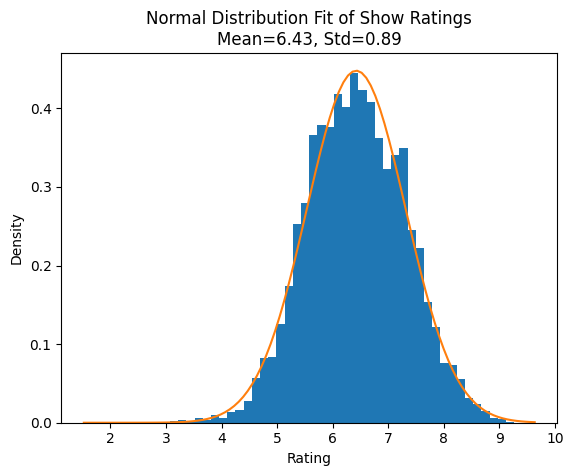

In [5]:
from scipy.stats import norm
score = df[["score"]].dropna()

plt.hist(score,bins=50,density=True)
mu, std = norm.fit(score)

xmin, xmax = plt.xlim()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,mu,std)

plt.plot(x,p)

plt.title(f"Normal Distribution Fit of Show Ratings\nMean={mu:.2f}, Std={std:.2f}")

plt.xlabel("Rating")
plt.ylabel("Density")

plt.show()

In [6]:
from scipy import stats

anime_rating_mean = np.mean(score)
anime_rating_median = np.median(score)
anime_rating_mode = stats.mode(score)
mode_val = anime_rating_mode.mode

print(anime_rating_mean)
print(anime_rating_median)
print(mode_val)

# Mean = Median = Mode Normal distribution, not skewed left or right
# If right skew then a few higher ratings are pulling mean higher
# If left skew then a few lower ratings are pulling mean lower


6.425589684295194
6.41
[6.43]


In [7]:
# Determine whether data is within 68% of 1 SD
std = np.std(score)

upper_bound = anime_rating_mean + std
lower_bound = anime_rating_mean - std

total_count = np.count_nonzero(score) # Total Population size
in_range_count = np.count_nonzero((score <= upper_bound) & (score >= lower_bound)) # Count of entries within the range of std

percent_within_std = (in_range_count/total_count) * 100 

print(f"{percent_within_std:.2f}%") # Close to 68% thus meaning normal data?



67.87%


In [8]:
bottom_5 = np.percentile(score,5)
top_5 = np.percentile(score,95)
print(bottom_5, top_5)

print(df.title[(df.score <= bottom_5)])
print(df.title[(df.score >= top_5)])


5.01 7.88
91                                 Chou Henshin Cosprayers
387                                        Hametsu no Mars
563                                          Legend of Duo
650      Chou Henshin Cosprayers vs. Ankoku Uchuu Shoug...
670                               Houkago no Shokuinshitsu
                               ...                        
27831                                       Twins Hinahima
29697    Mamonogurai no Boukensha: Ore dake Mamono wo K...
29698    Mamonogurai no Boukensha: Ore dake Mamono wo K...
29780                     Daikenja Riddle no Jikan Gyakkou
29781                     Daikenja Riddle no Jikan Gyakkou
Name: title, Length: 1002, dtype: str
0                            Cowboy Bebop
1         Cowboy Bebop: Tengoku no Tobira
2                                  Trigun
5                            Eyeshield 21
6                    Hachimitsu to Clover
                       ...               
29184    Dr. Stone: Science Future Part 3
29412    

In [9]:
# Testing for normality of data Shapiro Wilk Test
sample = score.sample(5000, random_state=42)
stat, p = stats.shapiro(sample)
print("Wilk: ", stat, "\nP Value: ", p)
# If P < 0.05 then reject normality
# Although the P is less than 0.05 histogram, Shapiro test, and percent within 1 SD is all normal thus data for anime ratings is normal

kurt = stats.kurtosis(score)
print("Kurtosis: ", kurt)
# Values of kurt 0 +/-2 are considered normal
# If kurt > 0 higher peak, more extreme outliers
# If kurt < 0 lower peak, less extreme outliers
# IF kurt = 0 normal distribution


skew = stats.skew(score)
print("Skew: ",skew)
# Skew = 0 normal, > 0 more weight in left tail, < 0 more weight in right tail

Wilk:  0.9968089706216513 
P Value:  7.569244623205788e-09
Kurtosis:  [0.09858712]
Skew:  [-0.07185511]


In [10]:
# Pearson or Spearman Corrlation
# Find the correlation between anime # of EP and rating scores

df_clean = df[["score","episodes"]].dropna() # Drops all NA in df of columns score and episodes
score_clean = df_clean["score"] # Gets all scores
eps_clean = df_clean["episodes"] # Gets all animes with episodes
r,p = stats.spearmanr(score_clean,eps_clean)

print(r,p)

0.3490652091827231 0.0


(array([0.00477194, 0.        , 0.        , 0.        , 0.00477194,
        0.01431582, 0.00477194, 0.01431582, 0.00954388, 0.0238597 ,
        0.04294746, 0.07157909, 0.10975461, 0.09066685, 0.13361431,
        0.12884237, 0.11452655, 0.14793012, 0.19564952, 0.27200055,
        0.28631637, 0.314948  , 0.37698322, 0.40084292, 0.45333425,
        0.52968528, 0.32926382, 0.41038679, 0.54877304, 0.7253348 ,
        0.52968528, 0.52491334, 0.5440011 , 0.44856231, 0.31971994,
        0.40084292, 0.26245667, 0.26245667, 0.23859697, 0.21473728,
        0.13361431, 0.10975461, 0.06203521, 0.05726327, 0.05726327,
        0.02863164, 0.0238597 , 0.04294746, 0.01431582, 0.00477194]),
 array([4.29  , 4.3896, 4.4892, 4.5888, 4.6884, 4.788 , 4.8876, 4.9872,
        5.0868, 5.1864, 5.286 , 5.3856, 5.4852, 5.5848, 5.6844, 5.784 ,
        5.8836, 5.9832, 6.0828, 6.1824, 6.282 , 6.3816, 6.4812, 6.5808,
        6.6804, 6.78  , 6.8796, 6.9792, 7.0788, 7.1784, 7.278 , 7.3776,
        7.4772, 7.5768, 7.6764

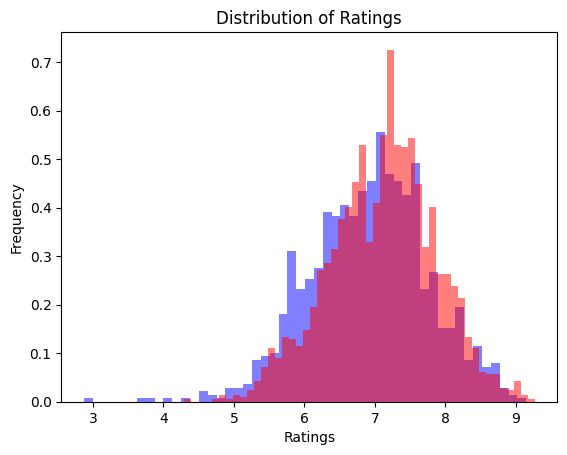

In [11]:
# Comparison of the two different types of genres and their ratings

# Take NA scores, and NA episodes out
# Compare Seinen and Shounen similar but different 
seinen_df = df[df["demographics"].str.contains("Seinen", na=False)]
shounen_df = df[df["demographics"].str.contains("Shounen", na=False)]

clean_seinen_score = seinen_df["score"].dropna()
clean_shounen_score = shounen_df["score"].dropna()
plt.title("Distribution of Ratings")
plt.xlabel("Ratings")
plt.ylabel("Frequency")
plt.hist(clean_seinen_score,50,density=True,alpha=0.5,label="Seinen", color="blue")
plt.hist(clean_shounen_score,50,density=True,alpha=0.5,label="Shounen",color= "Red")


In [12]:
#Scaling the scores to 0-1
#Cleaning unwanted fields types
#Using type, source, age-rating, aniscore, episodes, genres, studios, themes, demographics to determine recommendations
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

cleaned_data = df.dropna(
    subset=['type', 'source', 'rating', 'score', 'genres', 'studios']
).copy()

source_keep = {
    'Original', 'Manga', 'Light novel', 'Game', 'Visual novel',
    '4-koma manga', 'Novel', 'Web manga', 'Web novel'
}

type_keep = {
    'TV', 'Movie', 'OVA', 'TV Special', 'Special', 'ONA'
}

cleaned_data = cleaned_data[
    cleaned_data["source"].isin(source_keep) &
    cleaned_data["type"].isin(type_keep)
].copy()

cleaned_data['scaledScore'] = scaler.fit_transform(cleaned_data[['score']])

cleaned_data['themes'] = cleaned_data['themes'].fillna("")
cleaned_data['demographics'] = cleaned_data['demographics'].fillna("")
cleaned_data['genres'] = cleaned_data["genres"].fillna("")

Ordinal encoding for age ratings 
Multi hot encoding for genres, demographics, and themes
Frequency encoding for studios 
OHE for type, source 
MinMaxScaling for scores 
Bin sorting for number of episodes( because of large range)

In [13]:
#Ordinal Encoding for ordinal ratings
from sklearn.preprocessing import OrdinalEncoder
rating_order = [['G - All Ages','PG - Children','PG-13 - Teens 13 or older','R - 17+ (violence & profanity)','R+ - Mild Nudity','Rx - Hentai']]

ord_encoder = OrdinalEncoder(categories = rating_order)
cleaned_data['encodedRating'] = ord_encoder.fit_transform(cleaned_data[['rating']]) + 1
cleaned_data[['encodedRating','scaledScore','title']].head()

,encodedRating,scaledScore,title
0,4.0,0.929539,Cowboy Bebop
1,4.0,0.879404,Cowboy Bebop: Tengoku no Tobira
2,3.0,0.857724,Trigun
3,3.0,0.726287,Witch Hunter Robin
4,2.0,0.693767,Bouken Ou Beet


In [14]:
# One Hot Encoding for Type and Source
from sklearn.preprocessing import OneHotEncoder
OHE = OneHotEncoder(
    categories=[
        ['TV', 'Movie', 'OVA', 'TV Special', 'Special', 'ONA'],
        ['Original', 'Manga', 'Light novel', 'Game', 'Visual novel','4-koma manga', 'Novel', 'Web manga', 'Web novel']
    ],
    sparse_output=False,
    handle_unknown="ignore"
)
encoded_type_source = OHE.fit_transform(cleaned_data[['type', 'source']]) #Encodes the data based upon the categories in the encoder
feature_names = OHE.get_feature_names_out(['type', 'source']) #Gets the feature names(columns names)
encoded_df = pd.DataFrame(encoded_type_source, columns = feature_names, index = cleaned_data.index) #Creates dataframe of the encoded values

cleaned_data = pd.concat([cleaned_data, encoded_df], axis=1)

# Features Column
type_source_columns = feature_names.tolist()


In [15]:
#Frequency Encoding for Studios
studio_parse = cleaned_data['studios'].str.split('|').explode().str.strip().value_counts(normalize=True)
cleaned_data['studioFreq'] = cleaned_data['studios'].apply(
    lambda x: sum(studio_parse.get(studio.strip(),0) for studio in x.split('|')) / len(x.split('|'))
)

# Feature studioFreq


In [16]:
#Multi hot encoding genre and demographics
#Bin Numeric -> labels?
genre_dummies = cleaned_data['genres'].str.get_dummies(sep='|').add_prefix("genre_")
cleaned_data = pd.concat([cleaned_data, genre_dummies], axis=1)
demographic_dummies = cleaned_data['demographics'].str.get_dummies(sep='|').add_prefix("demographics_")
cleaned_data = pd.concat([cleaned_data, demographic_dummies], axis=1)
theme_dummies = cleaned_data['themes'].str.get_dummies(sep='|').add_prefix("theme_")
cleaned_data = pd.concat([cleaned_data, theme_dummies], axis=1)

# Features
genre_columns = genre_dummies.columns.tolist()
demographic_columns = demographic_dummies.columns.tolist()
theme_columns = theme_dummies.columns.tolist()


episode_scaler = MinMaxScaler()
cleaned_data["episodesMissing"] = cleaned_data["episodes"].isna().astype(int)
cleaned_data["episodes"] = pd.to_numeric(cleaned_data["episodes"],errors = "coerce")

median_episodes = cleaned_data["episodes"].median()
cleaned_data["episodes"] = cleaned_data["episodes"].fillna(median_episodes)

cleaned_data['logEpisodes'] = np.log1p(cleaned_data['episodes'])
cleaned_data['scaledEpisodes'] = episode_scaler.fit_transform(cleaned_data[['logEpisodes']])

# Feature scaledEpisodes



In [ ]:
# Cosine Similarity
# N Episodes, Studios, Genres, Demographics, Type, Score, Source, Age rating
from sklearn.metrics.pairwise import cosine_similarity

feature_columns = (
    genre_columns +
    theme_columns +
    demographic_columns +
    type_source_columns +
    ['scaledEpisodes', 'scaledScore', 'encodedRating']
)
# Removed studioFreq

liked_anime = ['One Piece', 'Bleach', 'Jujutsu Kaisen', "JoJo's Bizarre Adventure: Stardust Crusaders"]

liked_rows = cleaned_data[cleaned_data["title"].isin(liked_anime) | cleaned_data["title_english"].isin(liked_anime)]

anime_features = cleaned_data[feature_columns]

liked_vector = anime_features.loc[liked_rows.index]

liked_profile = liked_vector.mean(axis = 0)

liked_profile.sort_values(ascending=False).head(20)

similarity_score = cosine_similarity(anime_features,liked_profile.values.reshape(1,-1)).flatten()

cleaned_data["recommendationScore"] = similarity_score

recommendations = cleaned_data.sort_values("recommendationScore", ascending=False)

recommendations = recommendations[~(recommendations["title"].isin(liked_anime) | recommendations["title_english"].isin(liked_anime))]

recommendations[
    ["title", "title_english", "genres", "themes", "demographics", "source", "type", "score", "recommendationScore"]
].head(25)

[0.82270512 0.77346962 0.92059765 ... 0.7393252  0.86824582 0.71421308]


,title,title_english,genres,themes,demographics,source,type,score,recommendationScore
16571,Bleach: Sennen Kessen-hen,Bleach: Thousand-Year Blood War,Action|Adventure|Supernatural,,Shounen,Manga,TV,8.98,0.986277
25422,Bleach: Sennen Kessen-hen - Soukoku-tan,Bleach: Thousand-Year Blood War - The Conflict,Action|Adventure|Supernatural,,Shounen,Manga,TV,8.67,0.986260
23635,Bleach: Sennen Kessen-hen - Ketsubetsu-tan,Bleach: Thousand-Year Blood War - The Separation,Action|Adventure|Supernatural,,Shounen,Manga,TV,8.70,0.986192
132,Shaman King,Shaman King,Action|Adventure|Supernatural,,Shounen,Manga,TV,7.74,0.978089
16830,Shaman King (2021),NaN,Action|Adventure|Supernatural,,Shounen,Manga,TV,6.91,0.977617
22312,Shaman King: Flowers,NaN,Action|Adventure|Supernatural,,Shounen,Manga,TV,6.60,0.977043
11119,JoJo no Kimyou na Bouken Part 4: Diamond wa Ku...,JoJo's Bizarre Adventure: Diamond Is Unbreakable,Action|Adventure,Super Power,Shounen,Manga,TV,8.51,0.974635
9400,JoJo no Kimyou na Bouken Part 3: Stardust Crus...,JoJo's Bizarre Adventure: Stardust Crusaders -...,Action|Adventure,Super Power,Shounen,Manga,TV,8.44,0.974371
28790,Yomi no Tsugai,Daemons of the Shadow Realm,Action|Adventure|Fantasy,,Shounen,Manga,TV,8.04,0.974040
26025,Jujutsu Kaisen: Shimetsu Kaiyuu - Zenpen,Jujutsu Kaisen: The Culling Game Part 1,Action|Supernatural,,Shounen,Manga,TV,8.64,0.964656
